In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,ExtraTreesClassifier,VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import warnings

warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv')
train.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [4]:
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv')
test.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,2,bell,smooth,white,bruises,15,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,numerous,meadows
1,2,6,bell,smooth,white,bruises,21,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,numerous,meadows
2,3,7,bell,scaly,white,bruises,7,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,scattered,meadows
3,4,9,bell,smooth,yellow,bruises,23,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows
4,5,11,convex,scaly,yellow,bruises,11,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,scattered,meadows


In [5]:
print(train.shape)
print(test.shape)

(7000, 26)
(1124, 25)


# Criteria 1 --> Identify data types of different columns

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

# Criteria 2 --> Present descriptive statistics of numerical columns

In [7]:
train.describe()

,ID,mushroom_id,number_of_bruises,ring-number
count,7000.000000,7000.000000,7000.000000,6964.000000
mean,3500.500000,3850.617714,5.459571,1.080988
std,2020.870275,2208.389867,7.723528,0.272836
min,1.000000,0.000000,0.000000,1.000000
25%,1750.750000,2000.750000,0.000000,1.000000
50%,3500.500000,3755.500000,0.000000,1.000000
75%,5250.250000,5602.250000,11.000000,1.000000
max,7000.000000,8118.000000,24.000000,2.000000


# Criteria 3 --> Identify and handle the missing values

In [8]:
# Save test ID for submission
id_col = test['ID'].copy()

# Drop ID columns and zero-variance columns
drop_cols = ['ID', 'mushroom_id', 'veil-color', 'veil-type']
# NOTE: we keep mushroom_id dropped here since it has no overlap with test
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols,  inplace=True)

X = train.drop(columns=['class']).copy()
y = train['class']
test = test.copy()

# --- FIX 1: Add odor_missing indicator BEFORE imputing ---
# When odor is NaN -> 97.9% edible. This is a powerful feature!
X['odor_missing']    = X['odor'].isna().astype(int)
test['odor_missing'] = test['odor'].isna().astype(int)

# --- FIX 2: Manual imputation to preserve correct dtypes ---
# Using ColumnTransformer for imputation silently converts ring-number (float) -> object,
# causing it to be OHE'd instead of scaled — this is a bug in your original code.
ring_num_mode  = X['ring-number'].mode()[0]
ring_type_mode = X['ring-type'].mode()[0]

for df in [X, test]:
    df['odor']        = df['odor'].fillna('none')          # 'none' = no odor category
    df['stalk-root']  = df['stalk-root'].fillna('missing') # explicit missing category
    df['ring-number'] = df['ring-number'].fillna(ring_num_mode)   # stays float64
    df['ring-type']   = df['ring-type'].fillna(ring_type_mode)

print("Missing values remaining in X:", X.isnull().sum().sum())
print("ring-number dtype (should be float64):", X['ring-number'].dtype)

Missing values remaining in X: 0
ring-number dtype (should be float64): float64


# Criteria 4--> Checking for duplicates

In [9]:
dups = X.duplicated().sum()
print(f"Duplicates in training features: {dups}")

Duplicates in training features: 0


# Criteria 5 --> Identifying and Handling Outliers

In [10]:
for col in ['number_of_bruises', 'ring-number']:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((X[col] < lo) | (X[col] > hi)).sum()
    print(f"{col}: {n_out} outliers (lower={lo:.2f}, upper={hi:.2f})")

number_of_bruises: 0 outliers (lower=-16.50, upper=27.50)
ring-number: 564 outliers (lower=1.00, upper=1.00)


# Criteria 6--> Present at least three visualizations and provide insights for the same

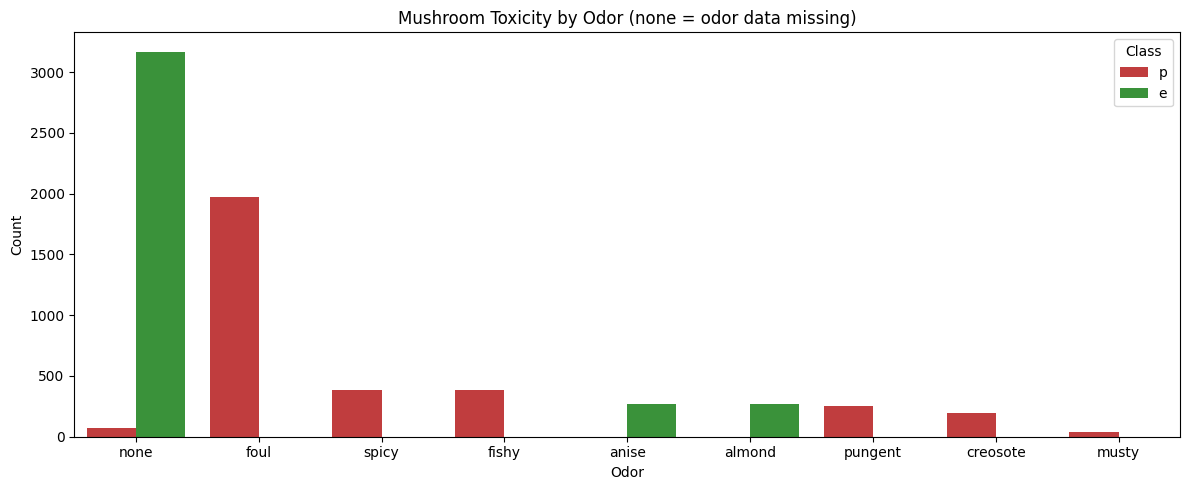

Insight: When odor=none (missing), mushrooms are overwhelmingly edible (97.9%).


In [11]:
# Viz 1: Odor vs Class (note: 'none' means odor was missing)
plt.figure(figsize=(12, 5))
order = X['odor'].value_counts().index
sns.countplot(data=X, x='odor', hue=y, order=order,
              palette={'e': '#2ca02c', 'p': '#d62728'})
plt.title('Mushroom Toxicity by Odor (none = odor data missing)')
plt.xlabel('Odor'); plt.ylabel('Count')
plt.legend(title='Class')
plt.tight_layout(); plt.show()
print("Insight: When odor=none (missing), mushrooms are overwhelmingly edible (97.9%).")

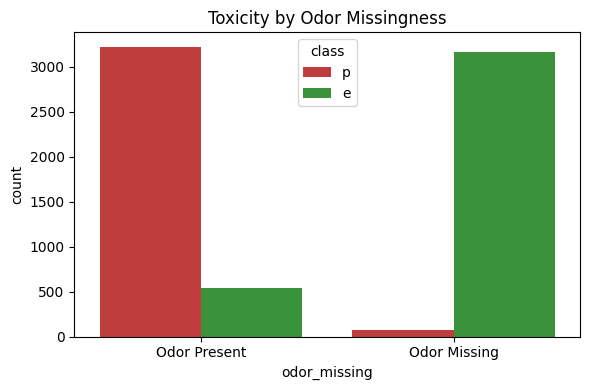

In [12]:
# Viz 2: odor_missing indicator vs class
plt.figure(figsize=(6, 4))
sns.countplot(data=X, x='odor_missing', hue=y,
              palette={'e':'#2ca02c','p':'#d62728'})
plt.xticks([0,1], ['Odor Present','Odor Missing'])
plt.title('Toxicity by Odor Missingness')
plt.tight_layout(); plt.show()

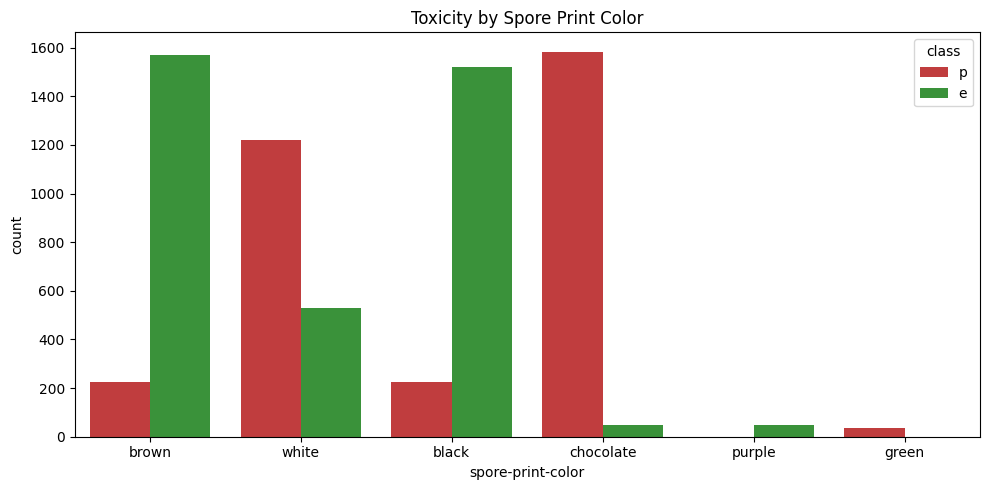

In [13]:
# Viz 3: Spore print color vs class
plt.figure(figsize=(10, 5))
order3 = X['spore-print-color'].value_counts().index
sns.countplot(data=X, x='spore-print-color', hue=y, order=order3,
              palette={'e':'#2ca02c','p':'#d62728'})
plt.title('Toxicity by Spore Print Color')
plt.tight_layout(); plt.show()

# Criteria 7 --> Scale Numerical features and Encode Categorical features

In [14]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
], verbose_feature_names_out=False)
preprocessor.set_output(transform='pandas')

X_enc  = preprocessor.fit_transform(X)
Xt_enc = preprocessor.transform(test)

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f"\nEncoded X_train shape: {X_enc.shape}")
print(f"Encoded X_test shape:  {Xt_enc.shape}")

Numerical columns: ['number_of_bruises', 'ring-number', 'odor_missing']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'ring-type', 'spore-print-color', 'population', 'habitat']

Encoded X_train shape: (7000, 99)
Encoded X_test shape:  (1124, 99)


# Criteria 8 --> Model Building

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest':  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees':    ExtraTreesClassifier(n_estimators=300,   random_state=42, n_jobs=-1),
}

for name, model in models.items():
    scores = cross_val_score(model, X_enc, y_enc, cv=skf, scoring='accuracy')
    print(f"{name}: CV={scores} | Mean={scores.mean():.4f} ± {scores.std():.4f}")

Random Forest: CV=[1. 1. 1. 1. 1.] | Mean=1.0000 ± 0.0000
Extra Trees: CV=[1. 1. 1. 1. 1.] | Mean=1.0000 ± 0.0000


# Criteria 9 --> Hyperparameter Tuning

In [16]:
# Soft-voting ensemble: combines probability estimates from both models
# This is more robust than any single model
rf = RandomForestClassifier(n_estimators=500, max_features='sqrt', random_state=42, n_jobs=-1)
et = ExtraTreesClassifier(n_estimators=500,   max_features='sqrt', random_state=42, n_jobs=-1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('et', et)],
    voting='soft',
    n_jobs=-1
)

cv_scores = cross_val_score(ensemble, X_enc, y_enc, cv=skf, scoring='accuracy')
print(f"Ensemble 5-Fold CV: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.6f}")

Ensemble 5-Fold CV: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.000000


# Criteria 10 --> Comparision of Model Performances

In [17]:
results = {}
all_models = {
    'Random Forest':  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees':    ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Ensemble (RF+ET)': VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=500, random_state=42, n_jobs=-1))
    ], voting='soft')
}
for name, m in all_models.items():
    s = cross_val_score(m, X_enc, y_enc, cv=skf, scoring='accuracy')
    results[name] = s.mean()
    print(f"{name}: {s.mean():.4f}")

comparison_df = pd.DataFrame(list(results.items()), columns=['Model','CV Accuracy'])
comparison_df = comparison_df.sort_values('CV Accuracy', ascending=False)
print("\n", comparison_df)

Random Forest: 1.0000
Extra Trees: 1.0000
Ensemble (RF+ET): 1.0000

               Model  CV Accuracy
0     Random Forest          1.0
1       Extra Trees          1.0
2  Ensemble (RF+ET)          1.0


In [18]:
# Fit on full training data and predict
ensemble.fit(X_enc, y_enc)
test_preds  = ensemble.predict(Xt_enc)
final_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({'ID': id_col.values, 'class': final_labels})
submission.to_csv('mushroom_submission.csv', index=False)

print("Submission saved!")
print(f"Prediction distribution: {pd.Series(final_labels).value_counts().to_dict()}")
submission.head(10)

Submission saved!
Prediction distribution: {'p': 620, 'e': 504}


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
5,6,e
6,7,e
7,8,e
8,9,e
9,10,e
